# Validation Diagnostics

Notebook per analizzare rapidamente i run di validazione (baseline, curriculum, rulebook).

In [7]:
from __future__ import annotations

import glob
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import yaml

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)


In [8]:
def nested_get(mapping: dict[str, Any], path: list[str], default: Any = None) -> Any:
    cur: Any = mapping
    for key in path:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def load_run_meta(run_dir: Path) -> dict[str, Any]:
    hydra_cfg = run_dir / 'hydra' / 'config.yaml'
    meta = {
        'run_dir': str(run_dir),
        'run_name': run_dir.name,
        'config_name': None,
        'curriculum_enabled': None,
        'curriculum_name': None,
        'reward_mode_cfg': None,
    }
    if not hydra_cfg.is_file():
        return meta

    try:
        cfg = yaml.safe_load(hydra_cfg.read_text(encoding='utf-8')) or {}
    except Exception:
        return meta

    # prova diversi path per robustezza su versioni/config diverse
    meta['config_name'] = (
        nested_get(cfg, ['metadata', 'config_name'])
        or nested_get(cfg, ['config_name'])
        or nested_get(cfg, ['hydra', 'job', 'config_name'])
    )
    meta['curriculum_enabled'] = nested_get(cfg, ['curriculum', 'enabled'])
    meta['curriculum_name'] = nested_get(cfg, ['curriculum', 'name'])
    meta['reward_mode_cfg'] = nested_get(cfg, ['reward', 'mode'])
    return meta


def read_promotions_summary(run_dir: Path) -> dict[str, Any]:
    promotions_path = run_dir / 'csv' / 'promotions.csv'
    out = {
        'num_promotions': 0,
        'max_stage_index_reached': None,
    }
    if not promotions_path.is_file():
        return out

    try:
        pdf = pd.read_csv(promotions_path)
    except Exception:
        return out

    if pdf.empty:
        return out

    out['num_promotions'] = int(len(pdf))
    stage_cols = [c for c in ['to_stage_index', 'stage_index'] if c in pdf.columns]
    if stage_cols:
        out['max_stage_index_reached'] = int(pd.to_numeric(pdf[stage_cols[0]], errors='coerce').dropna().max())
    return out


In [9]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'conf' / 'config.yaml').is_file():
            return candidate
    raise FileNotFoundError('Could not locate repo root (conf/config.yaml not found).')

repo_root = find_repo_root(Path.cwd().resolve())
pattern = str(repo_root / 'outputs' / '**' / 'csv' / 'final_eval.csv')
final_eval_files = sorted(glob.glob(pattern, recursive=True))
print(f'Repo root: {repo_root}')
print(f'Found final_eval.csv files: {len(final_eval_files)}')
if not final_eval_files:
    raise SystemExit(f'No final_eval.csv found under {pattern}')

rows = []
for fp in final_eval_files:
    run_dir = Path(fp).resolve().parent.parent
    df_row = pd.read_csv(fp)
    if df_row.empty:
        continue
    row = df_row.iloc[0].to_dict()
    row['final_eval_path'] = fp

    row.update(load_run_meta(run_dir))
    row.update(read_promotions_summary(run_dir))
    rows.append(row)

runs = pd.DataFrame(rows)
runs.shape


Repo root: /home/e.respino/main/thesis/thesis-metadrive
Found final_eval.csv files: 9


(9, 43)

In [10]:
display_cols = [
    'run_name', 'config_name', 'curriculum_enabled', 'curriculum_name',
    'reward_mode', 'reward_mode_cfg', 'seed',
    'success_rate', 'collision_rate', 'out_of_road_rate', 'route_completion',
    'top_rule_violation_rate', 'avg_error_value', 'max_error_value',
    'num_promotions', 'max_stage_index_reached'
]
display_cols = [c for c in display_cols if c in runs.columns]
runs.sort_values(['curriculum_enabled', 'reward_mode', 'seed'], na_position='last')[display_cols]


,run_name,config_name,curriculum_enabled,curriculum_name,reward_mode,reward_mode_cfg,seed,success_rate,collision_rate,out_of_road_rate,route_completion,top_rule_violation_rate,avg_error_value,max_error_value,num_promotions,max_stage_index_reached
0,20260505_164429,None,False,disabled,scalar_native,scalar_native,0,0.01,0.12,0.50,0.508431,0.0,0.000000,0.00000,0,NaN
1,20260505_164432,None,False,disabled,scalar_native,scalar_native,1,0.00,0.02,0.08,0.164500,0.0,0.000000,0.00000,0,NaN
2,20260505_164436,None,False,disabled,scalar_native,scalar_native,2,0.02,0.06,0.30,0.567474,0.0,0.000000,0.00000,0,NaN
3,20260505_164452,None,True,stages,scalar_native,scalar_native,0,0.00,0.46,0.56,0.280521,0.0,0.000000,0.00000,1,1.0
4,20260505_164445,None,True,stages,scalar_native,scalar_native,1,0.00,0.50,0.34,0.245186,0.0,0.000000,0.00000,0,NaN
5,20260505_164448,None,True,stages,scalar_native,scalar_native,2,0.01,0.38,0.61,0.214919,0.0,0.000000,0.00000,0,NaN
6,20260505_164523,None,True,stages,scalar_rulebook,scalar_rulebook,0,0.00,0.00,0.00,0.009194,0.0,100727.111980,342063.53125,0,NaN
7,20260505_164533,None,True,stages,scalar_rulebook,scalar_rulebook,1,0.00,0.00,0.00,0.009164,0.0,109246.295654,305883.50000,0,NaN
8,20260505_164543,None,True,stages,scalar_rulebook,scalar_rulebook,2,0.00,0.00,0.00,0.008894,0.0,118520.927690,347208.03125,0,NaN


In [11]:
# Aggregato medio/std per gruppo utile al confronto rapido
metric_cols = [
    c for c in [
        'success_rate', 'collision_rate', 'out_of_road_rate',
        'route_completion', 'top_rule_violation_rate',
        'avg_error_value', 'max_error_value'
    ] if c in runs.columns
]

group_cols = [c for c in ['curriculum_enabled', 'reward_mode'] if c in runs.columns]
summary = runs.groupby(group_cols, dropna=False)[metric_cols].agg(['mean', 'std', 'count'])
summary


success_rate                 collision_rate                 out_of_road_rate                 route_completion                 top_rule_violation_rate            avg_error_value  \
                                           mean       std count           mean       std count             mean       std count             mean       std count                    mean  std count            mean   
curriculum_enabled reward_mode                                                                                                                                                                                        
False              scalar_native       0.010000  0.010000     3       0.066667  0.050332     3         0.293333  0.210079     3         0.413468  0.217625     3                     0.0  0.0     3        0.000000   
True               scalar_native       0.003333  0.005774     3       0.446667  0.061101     3         0.503333  0.143643     3         0.246875  0.032833     3                     0.0  0.0     3        0.000000   
                   scalar_rulebook     0.000000  0.000000     3       0.000000  0.000000     3         0.000000  0.000000     3         0.009084  0.000165     3                     0.0  0.0     3   109498.111775   

                                                     max_error_value                      
                                           std count            mean           std count  
curriculum_enabled reward_mode                                                            
False              scalar_native       0.00000     3        0.000000      0.000000     3  
True               scalar_native       0.00000     3        0.000000      0.000000     3  
                   scalar_rulebook  8899.58021     3   331718.354167  22521.017682     3

/home/e.respino/main/thesis/thesis-metadrive/.venv/lib/python3.10/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


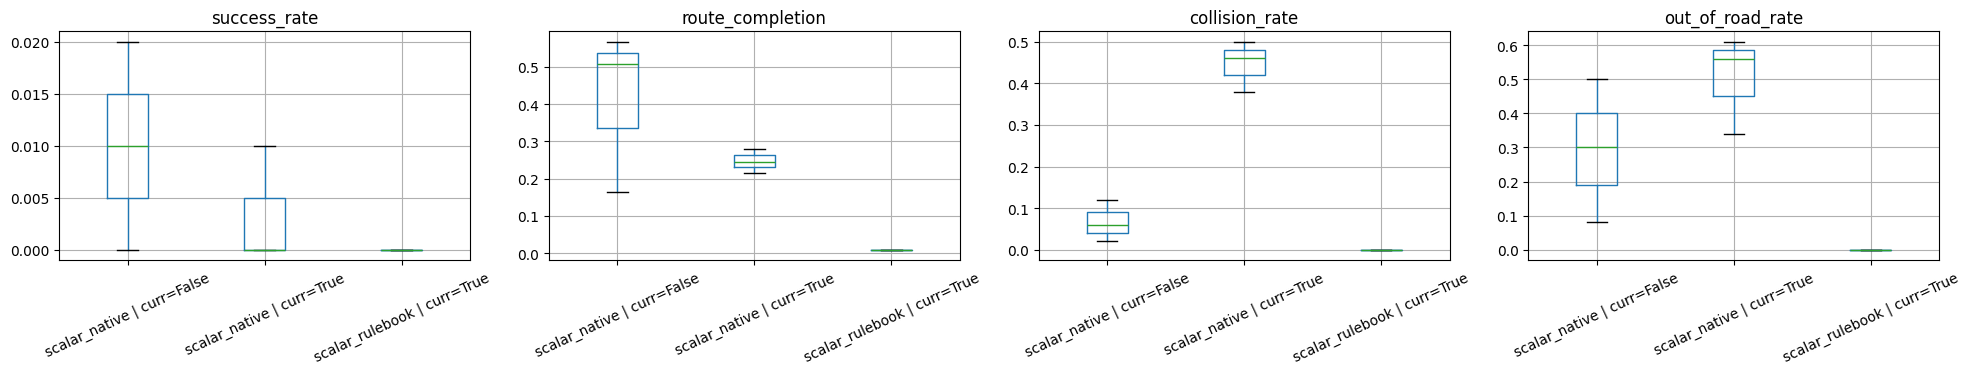

In [12]:
# Plot comparativo semplice su metriche chiave
plot_metrics = [m for m in ['success_rate', 'route_completion', 'collision_rate', 'out_of_road_rate'] if m in runs.columns]
if plot_metrics:
    n = len(plot_metrics)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    for i, m in enumerate(plot_metrics):
        ax = axes[0, i]
        tmp = runs[[c for c in ['reward_mode', 'curriculum_enabled', m] if c in runs.columns]].copy()
        tmp['group'] = tmp['reward_mode'].astype(str) + ' | curr=' + tmp['curriculum_enabled'].astype(str)
        tmp.boxplot(column=m, by='group', ax=ax, rot=25)
        ax.set_title(m)
        ax.set_xlabel('')
    plt.suptitle('')
    plt.tight_layout()
else:
    print('No plottable metrics found')


In [13]:
# Focus curriculum: quanto si promuove e dove arriva
curr_cols = [c for c in ['curriculum_enabled', 'reward_mode', 'seed', 'num_promotions', 'max_stage_index_reached', 'route_completion'] if c in runs.columns]
runs[runs.get('curriculum_enabled').fillna(False) == True][curr_cols].sort_values(['reward_mode', 'seed'])


,curriculum_enabled,reward_mode,seed,num_promotions,max_stage_index_reached,route_completion
3,True,scalar_native,0,1,1.0,0.280521
4,True,scalar_native,1,0,NaN,0.245186
5,True,scalar_native,2,0,NaN,0.214919
6,True,scalar_rulebook,0,0,NaN,0.009194
7,True,scalar_rulebook,1,0,NaN,0.009164
8,True,scalar_rulebook,2,0,NaN,0.008894
